In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from cleaning_utils import clean_dataset

In [2]:
raw_df = pd.read_csv('Huawei_Weekly_4G.csv')
df = clean_dataset(raw_df)
df.head()

C:\Users\hkizamou\AppData\Local\Temp\ipykernel_2276\2793524882.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv('Huawei_Weekly_4G.csv')


,Date,eNodeB_Name,Frequency_band,Cell_FDD_TDD_Indication,Cell_Name,LocalCell_Id,eNodeB_Function_Name,Integrity,CSSR_wo_VoLTE,DRC_wo_VoLTE,...,Avg_DL_PRB_Usage,Avg_UL_PRB_Usage,Avg_Traffic_User,DRC_wo_VoLTE_missing,Avg_DL_User_Thrput_kbps_missing,Avg_UL_User_Thrput_kbps_missing,Avg_DL_Traffic_Active_User_missing,Avg_UL_Traffic_Active_User_missing,Avg_DL_PRB_Usage_missing,Avg_UL_PRB_Usage_missing
0,2024-06-24,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_3_L800,13,0001_KKO_KATI_4G,100%,99.1530,0.9521,...,49.2775,15.0372,26.8633,False,False,False,False,False,False,False
1,2024-06-24,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_2_L800,12,0001_KKO_KATI_4G,100%,99.2467,0.7676,...,49.6515,16.8396,31.6133,False,False,False,False,False,False,False
2,2024-06-24,0001_KKO_KATI_SRAN_FO_GE_GE,20,CELL_FDD,0001_KKO_KATI_1_L800,11,0001_KKO_KATI_4G,100%,98.3222,0.8999,...,18.7620,7.9541,7.0259,False,False,False,False,False,False,False
3,2024-06-24,401_KAYES_SRAN_GE_GE,20,CELL_FDD,0401_KYS_KAY-LEGAL-SEGOU_3_L800,13,0401_KYS_KAY-LEGAL-SEGOU_4G,100%,99.6316,0.0715,...,26.4108,13.0305,11.9333,False,False,False,False,False,False,False
4,2024-06-24,401_KAYES_SRAN_GE_GE,20,CELL_FDD,0401_KYS_KAY-LEGAL-SEGOU_2_L800,12,0401_KYS_KAY-LEGAL-SEGOU_4G,100%,99.5652,0.1088,...,19.2749,9.9659,11.0457,False,False,False,False,False,False,False


### General Dataset Overview

In [3]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes.value_counts())
print("\nDetailed info:")
df.info()

Shape: (637887, 26)

Data Types:
float64           11
bool               7
string[python]     4
category           1
datetime64[ns]     1
category           1
category           1
Name: count, dtype: int64

Detailed info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 637887 entries, 0 to 637886
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   Date                                637887 non-null  datetime64[ns]
 1   eNodeB_Name                         637887 non-null  string        
 2   Frequency_band                      637887 non-null  category      
 3   Cell_FDD_TDD_Indication             637887 non-null  category      
 4   Cell_Name                           637887 non-null  string        
 5   LocalCell_Id                        637887 non-null  string        
 6   eNodeB_Function_Name                637887 non-null  string        
 7   Integ

In [4]:
# Missing flags summary
missing_flag_cols = ['DRC_wo_VoLTE_missing', 'Avg_DL_User_Thrput_kbps_missing', 'Avg_UL_User_Thrput_kbps_missing',
                    'Avg_DL_Traffic_Active_User_missing', 'Avg_UL_Traffic_Active_User_missing', 'Avg_DL_PRB_Usage_missing',
                    'Avg_UL_PRB_Usage_missing']

# Count of True/False per flag
for col in missing_flag_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(dropna=False))

# Count rows with any missing flag True
df['any_missing'] = df[missing_flag_cols].any(axis=1)
print("\nRows with any missing flag True:", df['any_missing'].sum())


DRC_wo_VoLTE_missing value counts:
DRC_wo_VoLTE_missing
False    631749
True       6138
Name: count, dtype: int64

Avg_DL_User_Thrput_kbps_missing value counts:
Avg_DL_User_Thrput_kbps_missing
False    633490
True       4397
Name: count, dtype: int64

Avg_UL_User_Thrput_kbps_missing value counts:
Avg_UL_User_Thrput_kbps_missing
False    633543
True       4344
Name: count, dtype: int64

Avg_DL_Traffic_Active_User_missing value counts:
Avg_DL_Traffic_Active_User_missing
False    637821
True         66
Name: count, dtype: int64

Avg_UL_Traffic_Active_User_missing value counts:
Avg_UL_Traffic_Active_User_missing
False    637821
True         66
Name: count, dtype: int64

Avg_DL_PRB_Usage_missing value counts:
Avg_DL_PRB_Usage_missing
False    633791
True       4096
Name: count, dtype: int64

Avg_UL_PRB_Usage_missing value counts:
Avg_UL_PRB_Usage_missing
False    633791
True       4096
Name: count, dtype: int64

Rows with any missing flag True: 6182


In [5]:
# Categorical summary
cat_cols = df.select_dtypes(include=['category']).columns
for col in cat_cols:
    print(f"\nColumns: {col}")
    print(df[col].value_counts(dropna=False))


Columns: Frequency_band
Frequency_band
20    253099
3     196572
28    113849
7      73431
40       936
Name: count, dtype: int64

Columns: Cell_FDD_TDD_Indication
Cell_FDD_TDD_Indication
CELL_FDD    636951
CELL_TDD       936
Name: count, dtype: int64

Columns: Integrity
Integrity
100%    473338
99%      31340
98%      25536
97%      14525
95%       9902
         ...  
17%         43
12%         42
18%         36
6%          30
3%          21
Name: count, Length: 101, dtype: int64


In [6]:
# Date summary
print(f"\nDate Range: {df['Date'].min()} to {df['Date'].max()}")
print("Date Frequency Breakdown:")
print(df['Date'].dt.to_period('M').value_counts().sort_index())


Date Range: 2024-06-24 00:00:00 to 2025-06-16 00:00:00
Date Frequency Breakdown:
Date
2024-06    11453
2024-07    57394
2024-08    45931
2024-09    57379
2024-10    46051
2024-11    47163
2024-12    60782
2025-01    50906
2025-02    51472
2025-03    65164
2025-04    52422
2025-05    52482
2025-06    39288
Freq: M, Name: count, dtype: int64


In [7]:
# Descriptive stats for numeric columns
numeric_cols = df.select_dtypes(include=['float', 'int']).columns
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
CSSR_wo_VoLTE,637887.0,98.676049,9.786096,0.0,99.5950,99.8041,99.89990,100.0000
DRC_wo_VoLTE,637887.0,0.267352,0.418805,0.0,0.0703,0.1635,0.33520,33.3333
Avg_DL_User_Thrput_kbps,637887.0,19864.227127,10811.310170,0.0,11966.7372,18600.4920,26407.88460,92822.2999
UL_Traffic_Volume_GBytes,637887.0,48.557366,52.538122,0.0,12.9028,32.4062,66.93555,1533.3606
Avg_UL_User_Thrput_kbps,637887.0,3681.655278,1430.823574,0.0,2776.6245,3701.2164,4518.71310,36056.2082
DL_Traffic_Volume_GBytes,637887.0,441.609354,444.862934,0.0,117.0955,299.1182,622.59805,5421.2819
Avg_DL_Traffic_Active_User,637887.0,1.208082,4.376761,0.0,0.1534,0.3822,0.87340,164.0017
Avg_UL_Traffic_Active_User,637887.0,0.821422,1.706165,0.0,0.2154,0.4944,0.98490,122.4558
Avg_DL_PRB_Usage,637887.0,23.355193,17.861005,0.0,9.8818,18.7941,31.97950,99.7661
Avg_UL_PRB_Usage,637887.0,12.564359,7.783179,0.0,7.4079,10.2116,15.43900,89.5558


### Univariate Analysis

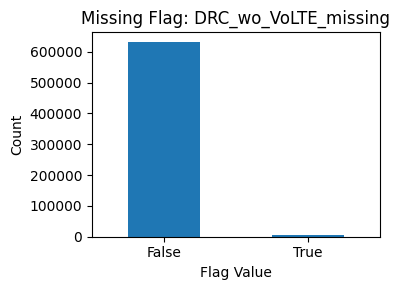

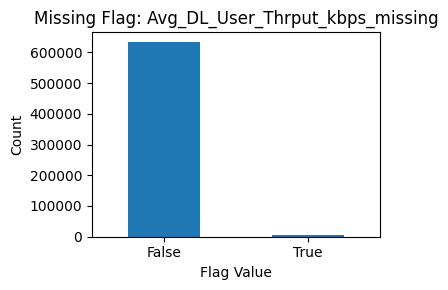

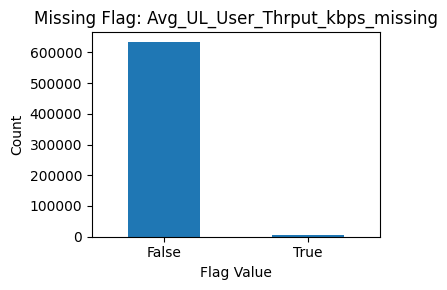

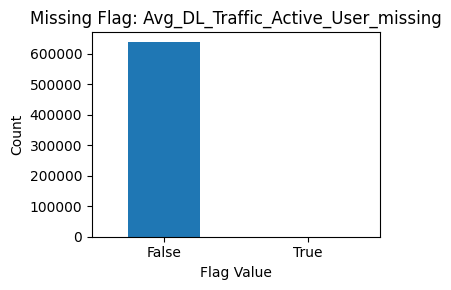

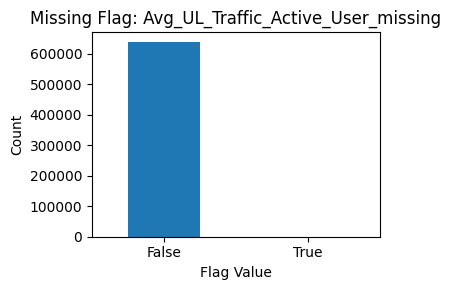

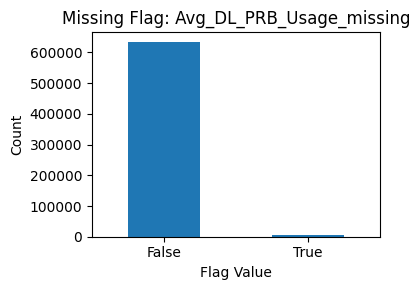

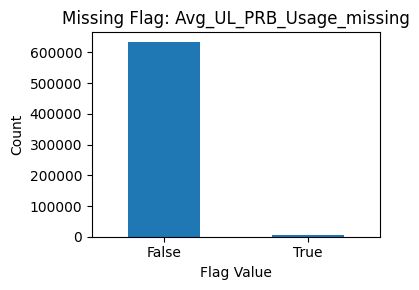

In [8]:
# Bar plots
for col in missing_flag_cols:
    plt.figure(figsize=(4, 3))
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Missing Flag: {col}')
    plt.xlabel('Flag Value')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

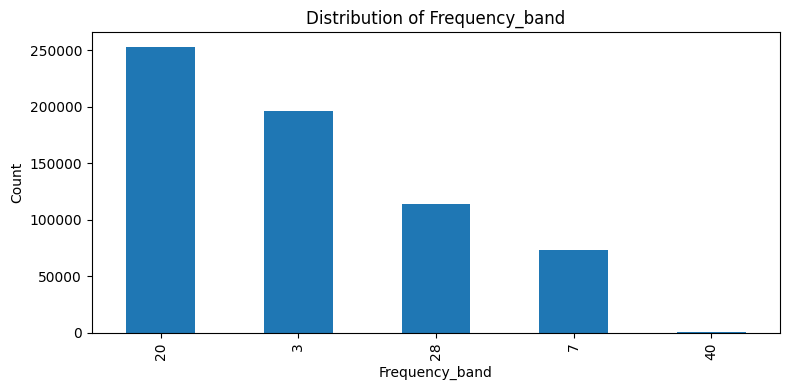

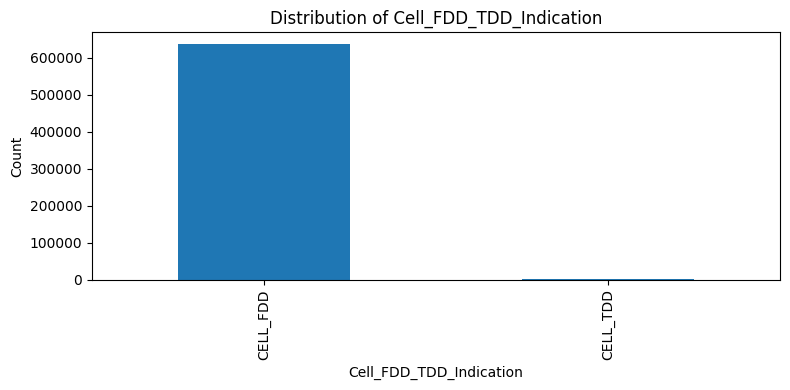

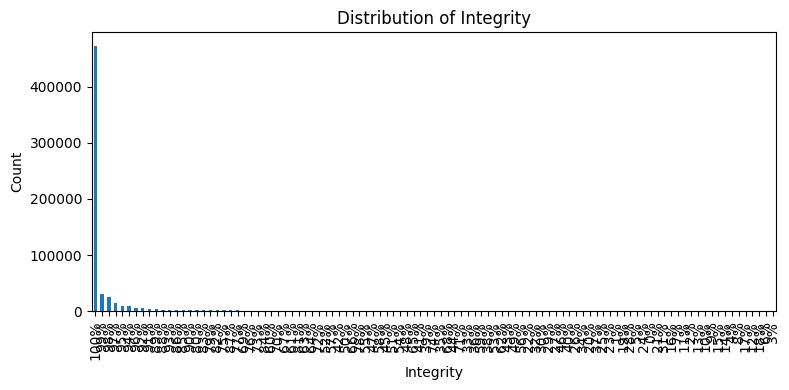

In [9]:
# Bar plots
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

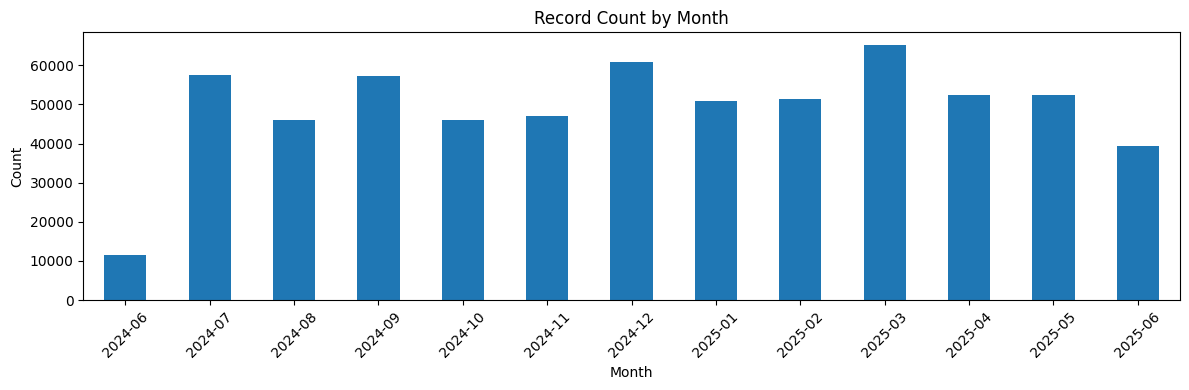

In [10]:
# Date summary
df['Date'].dt.to_period('M').value_counts().sort_index().plot(kind='bar', figsize=(12, 4))
plt.title('Record Count by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

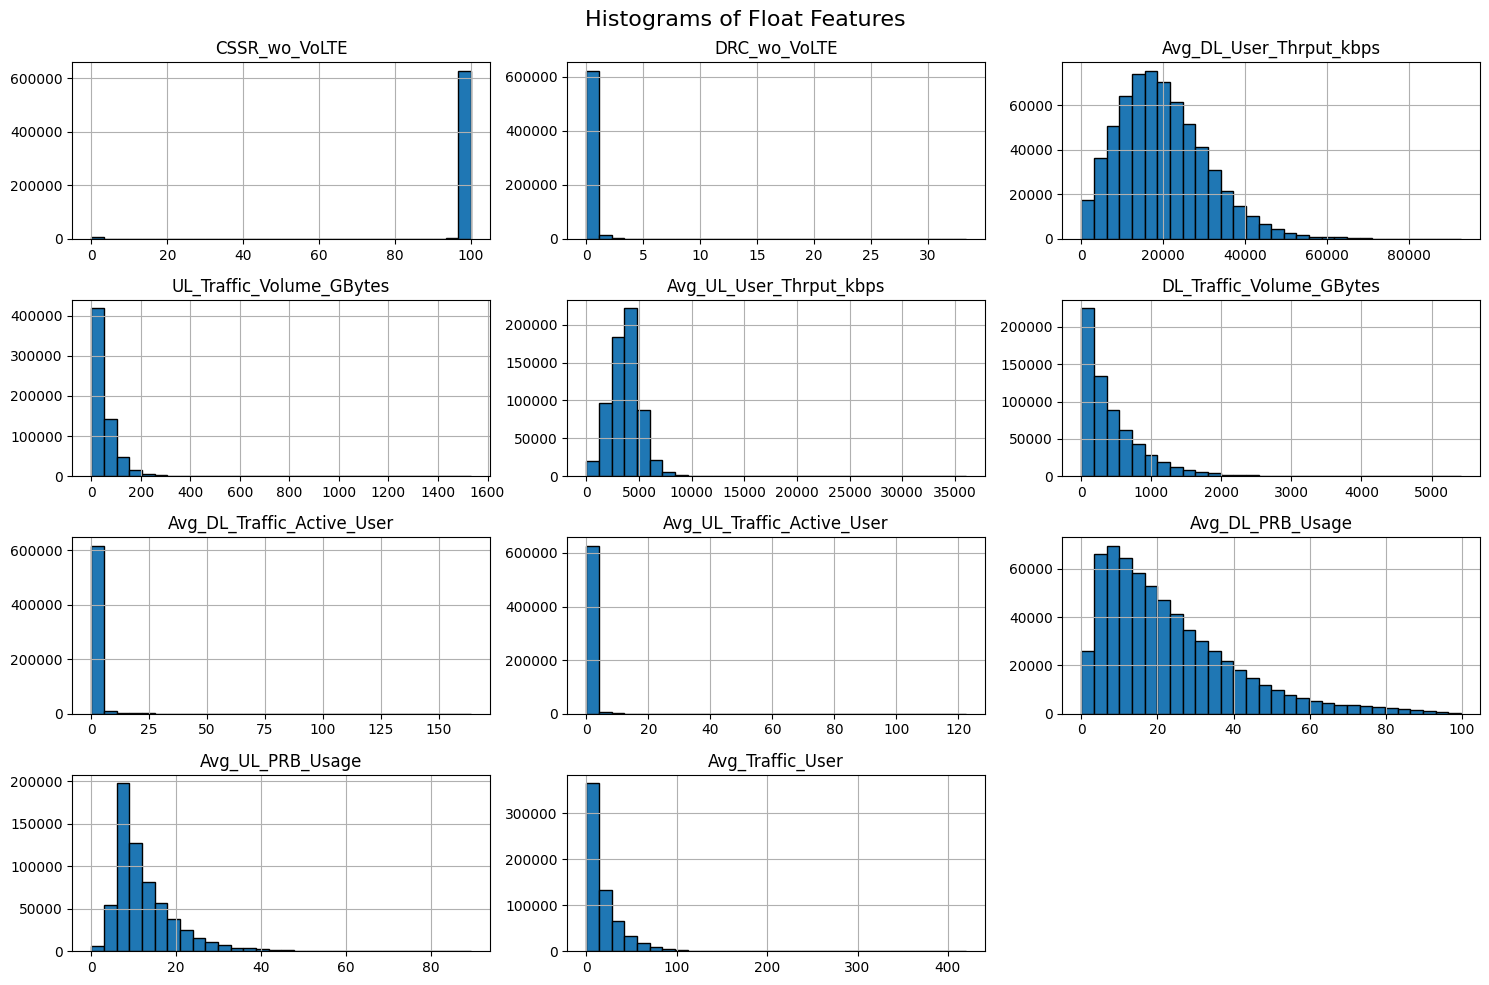

In [11]:
# Float columns histograms
df[numeric_cols].hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.suptitle('Histograms of Float Features', fontsize=16)
plt.tight_layout()
plt.show()

### Bivariate Analysis

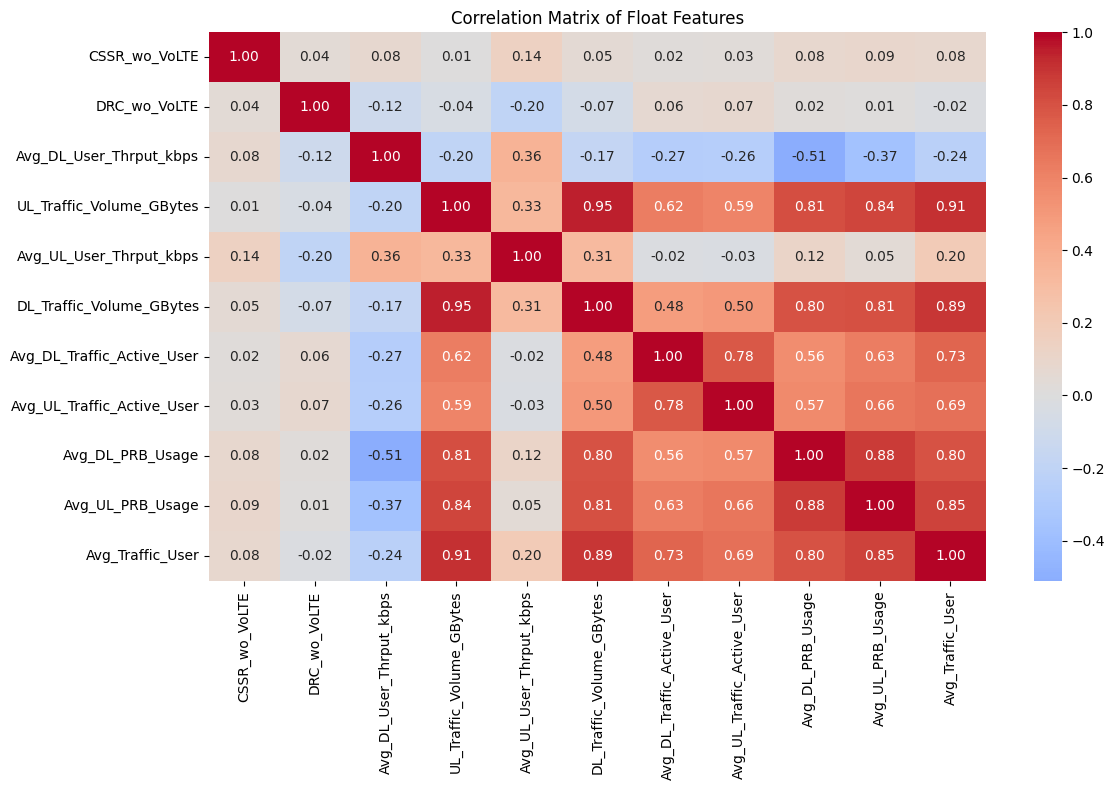

In [12]:
# Correlation Matrix
plt.figure(figsize=(12, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Float Features')
plt.tight_layout()
plt.show()

### Dimensionality Reduction & Redundancy Checks

In [13]:
from sklearn.preprocessing import StandardScaler

# Scale the float features
X_numeric = df[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

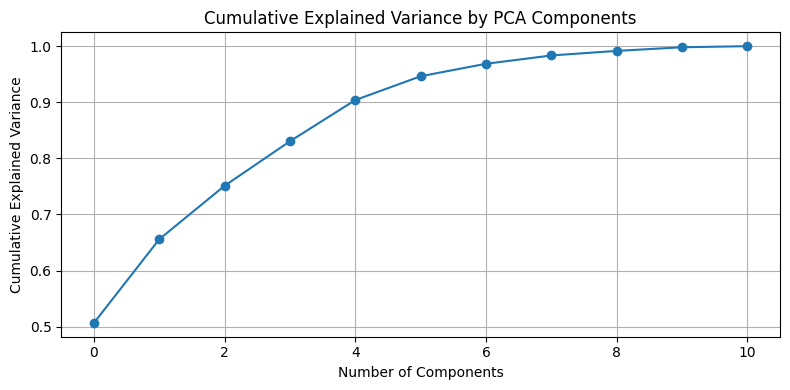

In [14]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

explained_var = pca.explained_variance_ratio_

plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(explained_var), marker='o')
plt.title('Cumulative Explained Variance by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.tight_layout()
plt.show()

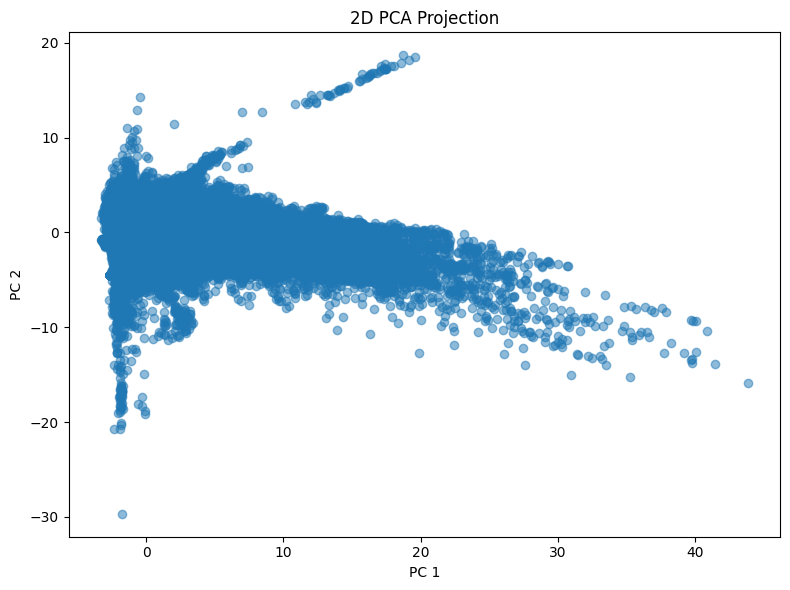

In [15]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title('2D PCA Projection')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.tight_layout()
plt.show()

In [16]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.utils import resample

def evaluate_clustering(X, labels):
    """
    Evaluate clustering performance using:
    - Silhouette Score
    - Davies-Bouldin Index
    - Calinski-Harabasz index
    """
    
    # Filter out noise points (e.g., from DBSCAN) if present
    if -1 in labels:
        X_valid = X[labels != -1]
        labels_valid = labels[labels != -1]
    else:
        X_valid = X
        labels_valid = labels

    results = {}

    silhouette_sample_size = 10000
    # Silhouette Score: compute on a sample
    try:
        X_sil, labels_sil = resample(X_valid, labels_valid, n_samples=silhouette_sample_size, random_state=42)
        results['Silhouette Score'] = silhouette_score(X_sil, labels_sil)
    except Exception as e:
        results['Silhouette Score'] = f"Error: {e}"

    try:
        results['Davies-Bouldin Index'] = davies_bouldin_score(X_valid, labels_valid)
    except Exception as e:
        results['Davies-Bouldin Index'] = f"Error: {e}"

    try:
        results['Calinski-Harabasz Index'] = calinski_harabasz_score(X_valid, labels_valid)
    except Exception as e:
        results['Calinski-Harabasz Index'] = f"Error: {e}"

    for metric, score in results.items():
        print(f"{metric}: {score}")

    return results

### K-Means

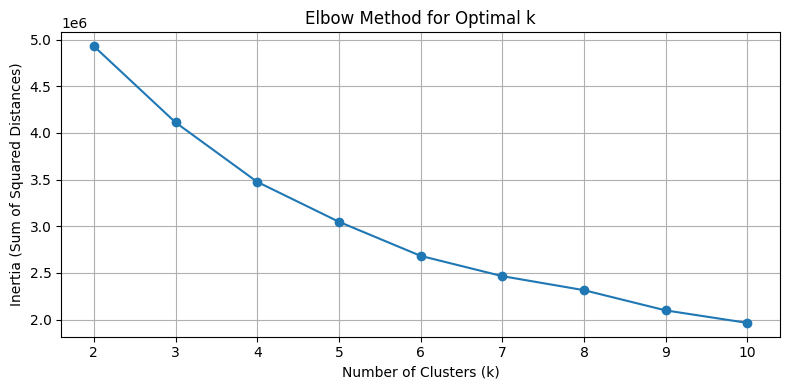

In [17]:
from sklearn.cluster import KMeans

# Elbow Method
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [18]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['cluster_kmeans'] = kmeans_labels

"""
Silhouette Score - Range: -1 to 1, The higher, the better
Davies-Bouldin Index - Range: >= 0, The lower, the better
Calinski-Harabasz Index - Range: >= 0, The higher, the better
"""
resullt = evaluate_clustering(X_scaled, kmeans_labels)

Silhouette Score: 0.2965498982309644
Davies-Bouldin Index: 1.0245992609262198
Calinski-Harabasz Index: 207625.94544313074


### GMM

In [19]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5, random_state=42)
gmm_labels = gmm.fit_predict(X_scaled)

df['cluster_gmm'] = gmm_labels

"""
Silhouette Score - Range: -1 to 1, The higher, the better
Davies-Bouldin Index - Range: >= 0, The lower, the better
Calinski-Harabasz Index - Range: >= 0, The higher, the better
"""
resullt = evaluate_clustering(X_scaled, gmm_labels)

Silhouette Score: 0.13112094041163502
Davies-Bouldin Index: 1.6761317840909
Calinski-Harabasz Index: 116460.81367802306


### HDBSCAN

In [20]:
import hdbscan

hdbscan = hdbscan.HDBSCAN(min_cluster_size=500)
hdbscan_labels = hdbscan.fit_predict(X_scaled)

df['cluster_hdbscan'] = hdbscan_labels

"""
Silhouette Score - Range: -1 to 1, The higher, the better
Davies-Bouldin Index - Range: >= 0, The lower, the better
Calinski-Harabasz Index - Range: >= 0, The higher, the better
"""
result = evaluate_clustering(X_scaled, hdbscan_labels)

C:\Users\hkizamou\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\hkizamou\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Silhouette Score: 0.6990485887169036
Davies-Bouldin Index: 0.29071736326738074
Calinski-Harabasz Index: 37280.20283177969
